In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns
from gstatot import StatOT, gStatOT, Metric_Evaluator, utils

sns.set_context("paper", font_scale=1.5)
sns.set_theme(style="ticks")

In [2]:
data_dir = '../data/sim_data/bistable_simulations'
sim_adata = sc.read_h5ad(f"{data_dir}/bistable_sim_seed=0.h5ad")

n = 10 
T = 25
chosen_times = np.linspace(2, 99, T, dtype=int)

sim_dt = dt =  0.01
num_step = int(2/dt) # 2 days
num_traj = sim_adata.uns['true_traj_data']['0.0'].shape[0] 

num_exp = 10
seed = 1

adata_keys  = {'time_key': 'chronological_age', 
               'cell_type_key': 'cell_type', 
               'growth_rate_key': 'growth_rate', 
               'embed_key': 'X_pca'}

model_params = { 
    'lam': 15,
    'epsilon2': 0.01
                    } 

SOT_params = {'epsilon': 0.075,
              'lse': True,
              'cost_scaling': 'mean'}

In [3]:
# Test multiplicitive noise
all_res = pd.DataFrame()

gr_noise = np.logspace(-2, 0, 10) # noise levels to add to growth rates
print("Noise levels to add to growth rates:", gr_noise)
key = jax.random.PRNGKey(seed)

for exp in range(num_exp):
    print(f"Experiment {exp+1}/{num_exp}")
    for noise_std in tqdm(gr_noise, desc="Noise levels"):

        sim_adata = sc.read_h5ad(f"{data_dir}/bistable_sim_seed={exp+1}.h5ad") 
        key, subkey = jax.random.split(key)
        downsampled_adata = utils.downsample_adata_by_age(sim_adata, n=n, time_key='chronological_age', PRNG_KEY=subkey, chosen_times=chosen_times)

        key, subkey = jax.random.split(key)
        noise1 = jax.random.normal(subkey, shape=(downsampled_adata.shape[0],)) * noise_std
        key, subkey = jax.random.split(key)

        key, subkey = jax.random.split(key)
        noise2 = jax.random.normal(subkey, shape=(downsampled_adata.shape[0],)) * noise_std

        downsampled_adata.obs['growth_rate'] += noise1 * downsampled_adata.obs['growth_rate'] + noise2 
    
        ds_copy = downsampled_adata.copy()
   
        gSOT = gStatOT(adata=ds_copy, adata_keys=adata_keys, dt=dt)
    

    
        gSOT.fit(model_params=model_params, tol=1e-3, max_iter=1000,verbose=False)
        gSOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], 
                                all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))
        gSOT.get_trajectories(num_step=num_step, num_traj=num_traj)
    
        method_str = 'gStatOT'
        metric_tests = Metric_Evaluator(method=method_str,
                                                test_adata=ds_copy,
                                                true_adata=sim_adata,
                                                time_key=adata_keys['time_key'],
                                                embed_key=adata_keys['embed_key'],
                                                exp_dir=None,
                                                plot_metrics=False
                                                )
    
        metric_tests.w2_marginal_error()
        metric_tests.fp_tv_error(label_key='cell_type')
        metric_tests.w2_trajectory_error(test_dt=dt, true_dt=sim_dt)
    
        res = metric_tests.results_df
        res['noise'] = noise_std
        res['exp'] = exp
        all_res = pd.concat([all_res, res], ignore_index=True)
    
        # StatOT
        ds_copy = downsampled_adata.copy()
        
        SOT = StatOT(adata=ds_copy, adata_keys=adata_keys, dt=dt, dtype=jnp.float32)
    

        SOT.fit(model_params=SOT_params, max_iter=15_000, verbose=False)
    
        SOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], 
                                all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))
    
        SOT.get_trajectories(num_step=num_step, num_traj=num_traj)
        method_str = 'StatOT'
    
        sot_metric_tests = Metric_Evaluator(method=method_str,
                                                test_adata=ds_copy,
                                                true_adata=sim_adata,
                                                time_key=adata_keys['time_key'],
                                                embed_key=adata_keys['embed_key'],
                                                exp_dir=None,
                                                full_supp=False,
                                                plot_metrics=False
                                                )
        sot_metric_tests.w2_marginal_error()
        sot_metric_tests.fp_tv_error(label_key='cell_type')
        sot_metric_tests.w2_trajectory_error(test_dt=dt, true_dt=sim_dt)
    
        sot_res = sot_metric_tests.results_df
        sot_res['noise'] = noise_std
        sot_res['exp'] = exp
        all_res = pd.concat([all_res, sot_res], ignore_index=True)
        all_res.to_csv('./growth_rate_stability_results.csv', index=False)

Noise levels to add to growth rates: [0.01       0.01668101 0.02782559 0.04641589 0.07742637 0.12915497
 0.21544347 0.35938137 0.59948425 1.        ]
Experiment 1/10


Noise levels: 100%|██████████| 10/10 [03:47<00:00, 22.75s/it]


Experiment 2/10


Noise levels:  40%|████      | 4/10 [01:35<02:21, 23.61s/it]

No sinks at time 78.0, cannot compute fate probabilities.


...

Noise levels: 100%|██████████| 10/10 [03:45<00:00, 22.59s/it]


Experiment 10/10


Noise levels:  40%|████      | 4/10 [01:33<02:24, 24.01s/it]

Age 18.0: Restarting due to high fate prob error: 9.82883e-01 (tol=0.01). 10 restarts remaining.
Age 18.0: Restarting due to high fate prob error: 9.82883e-01 (tol=0.01). 9 restarts remaining.
Age 18.0: Restarting due to high fate prob error: 9.82883e-01 (tol=0.01). 8 restarts remaining.
Age 18.0: Restarting due to high fate prob error: 9.82883e-01 (tol=0.01). 7 restarts remaining.
Age 18.0: Restarting due to high fate prob error: 9.82883e-01 (tol=0.01). 6 restarts remaining.
Age 18.0: Restarting due to high fate prob error: 9.82883e-01 (tol=0.01). 5 restarts remaining.


Noise levels: 100%|██████████| 10/10 [03:50<00:00, 23.08s/it]


In [4]:
# Test with change in growth distribution

all_res = pd.DataFrame()
key = jax.random.PRNGKey(seed)
gr_noise = np.linspace(0, 2, 10) # radius of region around origin to add growth rate noncommitted cells

for exp in range(num_exp):
    print(f"Experiment {exp+1}/{num_exp}")
    for noise_std in tqdm(gr_noise, desc="Noise levels"):

        sim_adata = sc.read_h5ad(f"{data_dir}/bistable_sim_seed={exp+1}.h5ad") # load sim adata with ground truth trajectories and fate probability estimates
        key, subkey = jax.random.split(key)
        downsampled_adata = utils.downsample_adata_by_age(sim_adata, n=n, time_key='chronological_age', PRNG_KEY=subkey, chosen_times=chosen_times)

        gr = downsampled_adata.obs['growth_rate'].values
        # add origin gr to other noncommitted cells
        points_near_0 = (downsampled_adata.X[:,0] < noise_std) & (np.abs(downsampled_adata.X[:,1]) < 0.5)
        downsampled_adata.obs.loc[points_near_0, 'growth_rate'] = 100
    
        ds_copy = downsampled_adata.copy()
   
        gSOT = gStatOT(adata=ds_copy, adata_keys=adata_keys, dt=dt)
    
        gSOT.fit(model_params=model_params, tol=1e-3, max_iter=1000, verbose=False)
        gSOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], 
                                all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))
        gSOT.get_trajectories(num_step=num_step, num_traj=num_traj)
    
        method_str = 'gStatOT'
        metric_tests = Metric_Evaluator(method=method_str,
                                                test_adata=ds_copy,
                                                true_adata=sim_adata,
                                                time_key=adata_keys['time_key'],
                                                embed_key=adata_keys['embed_key'],
                                                exp_dir=None,
                                                plot_metrics=False
                                                )
    
        metric_tests.w2_marginal_error()
        metric_tests.fp_tv_error(label_key='cell_type')
        metric_tests.w2_trajectory_error(test_dt=dt, true_dt=sim_dt)
    
        res = metric_tests.results_df
        res['noise'] = noise_std
        res['exp'] = exp
        all_res = pd.concat([all_res, res], ignore_index=True)

    
        # StatOT
        ds_copy = downsampled_adata.copy()

        SOT = StatOT(adata=ds_copy, adata_keys=adata_keys, dt=dt, dtype=jnp.float32)
    
    
        SOT.fit(model_params=SOT_params, max_iter=15_000, verbose=False)
    
        SOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], 
                                all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))
    
        SOT.get_trajectories(num_step=num_step, num_traj=num_traj)
        method_str = 'StatOT'
    
        sot_metric_tests = Metric_Evaluator(method=method_str,
                                                test_adata=ds_copy,
                                                true_adata=sim_adata,
                                                time_key=adata_keys['time_key'],
                                                embed_key=adata_keys['embed_key'],
                                                exp_dir=None,
                                                full_supp=False,
                                                plot_metrics=False
                                                )
        sot_metric_tests.w2_marginal_error()
        sot_metric_tests.fp_tv_error(label_key='cell_type')
        sot_metric_tests.w2_trajectory_error(test_dt=dt, true_dt=sim_dt)
    
        sot_res = sot_metric_tests.results_df
        sot_res['noise'] = noise_std
        sot_res['exp'] = exp
        all_res = pd.concat([all_res, sot_res], ignore_index=True)
        all_res.to_csv('./growth_rate_stability_results_peterb_sources.csv', index=False)

Experiment 1/10


Noise levels:   0%|          | 0/10 [00:00<?, ?it/s]

No sinks at time 6.0, cannot compute fate probabilities.
No sinks at time 50.0, cannot compute fate probabilities.


Noise levels:  10%|█         | 1/10 [00:23<03:32, 23.59s/it]

No sinks at time 2.0, cannot compute fate probabilities.
No sinks at time 6.0, cannot compute fate probabilities.
No sinks at time 42.0, cannot compute fate probabilities.
No sinks at time 50.0, cannot compute fate probabilities.
No sinks at time 66.0, cannot compute fate probabilities.
No sinks at time 74.0, cannot compute fate probabilities.
No sinks at time 86.0, cannot compute fate probabilities.


...

Noise levels:  80%|████████  | 8/10 [03:08<00:51, 25.71s/it]

No sinks at time 18.0, cannot compute fate probabilities.
No sinks at time 22.0, cannot compute fate probabilities.
No sinks at time 26.0, cannot compute fate probabilities.
No sinks at time 30.0, cannot compute fate probabilities.
No sinks at time 34.0, cannot compute fate probabilities.
No sinks at time 54.0, cannot compute fate probabilities.
No sinks at time 58.0, cannot compute fate probabilities.
No sinks at time 62.0, cannot compute fate probabilities.
No sinks at time 99.0, cannot compute fate probabilities.


Noise levels:  90%|█████████ | 9/10 [03:33<00:25, 25.30s/it]

No sinks at time 10.0, cannot compute fate probabilities.
No sinks at time 30.0, cannot compute fate probabilities.
No sinks at time 58.0, cannot compute fate probabilities.
No sinks at time 62.0, cannot compute fate probabilities.
No sinks at time 66.0, cannot compute fate probabilities.
No sinks at time 74.0, cannot compute fate probabilities.


Noise levels: 100%|██████████| 10/10 [03:57<00:00, 23.77s/it]


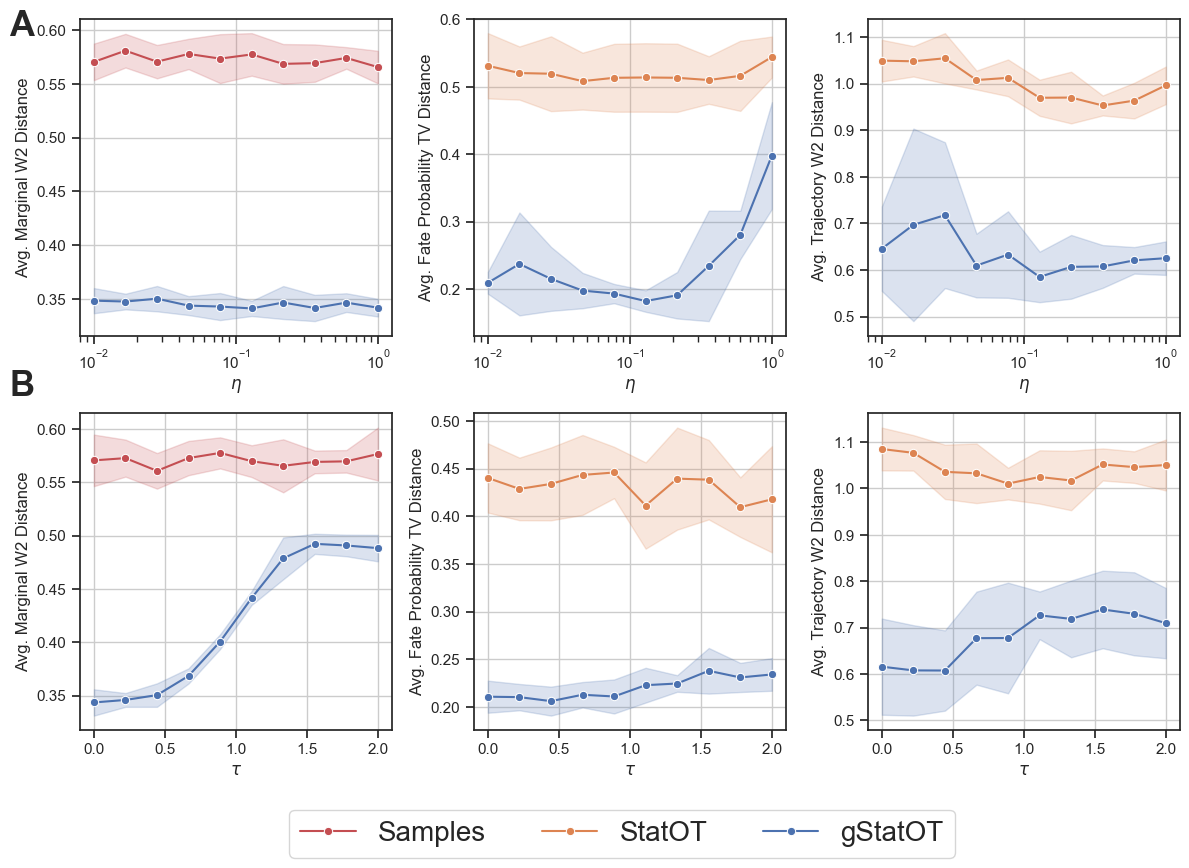

In [5]:
sns.set_style("ticks")
all_res_add = pd.read_csv('./growth_rate_stability_results.csv')
all_res_peterb = pd.read_csv('./growth_rate_stability_results_peterb_sources.csv')


fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# additive noise results
ax1, ax2, ax3 = axes[0]
all_res = all_res_add.copy()
# average across age
all_res = all_res.groupby(['method', 'noise', 'exp'], as_index=False).mean()
all_res_w2 = all_res.copy()
all_res_w2.loc[all_res_w2['method'] == 'StatOT', 'method'] = 'Samples'
cols = sns.color_palette("deep", n_colors=4)
methods = ["Samples", "StatOT", "gStatOT"]
palette = {
    methods[0]: cols[3], 
    methods[1]: cols[1],
    methods[2]: cols[0],
}

sns.lineplot(data=all_res_w2, x='noise', y='marginal_W2_dist', hue='method', ax=ax1, marker='o', palette=palette  , errorbar='sd'  )
sns.lineplot(data=all_res, x='noise', y='FP_TV_dist', hue='method', ax=ax2, marker='o', palette=palette , errorbar='sd'  )
sns.lineplot(data=all_res, x='noise', y='traj_W2_dist', hue='method', ax=ax3, marker='o', palette=palette, errorbar='sd'  )
xlabel = r'$\eta$'

ax1.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')
ax1.set_xlabel(xlabel)
ax2.set_xlabel(xlabel)
ax3.set_xlabel(xlabel)
ax1.legend().remove()
ax2.legend().remove()
ax3.legend().remove()
ax1.grid()
ax2.grid()
ax3.grid()

ax1.set_ylabel('Avg. Marginal W2 Distance')
ax2.set_ylabel('Avg. Fate Probability TV Distance')
ax3.set_ylabel('Avg. Trajectory W2 Distance')

# source perturbation results
ax1, ax2, ax3 = axes[1]
all_res = all_res_peterb.copy()
all_res = all_res.groupby(['method', 'noise', 'exp'], as_index=False).mean() # average across age
all_res_w2 = all_res.copy()
all_res_w2.loc[all_res_w2['method'] == 'StatOT', 'method'] = 'Samples'
cols = sns.color_palette("deep", n_colors=4)

sns.lineplot(data=all_res_w2, x='noise', y='marginal_W2_dist', hue='method', ax=ax1, marker='o', palette=palette  , errorbar='sd'  )
sns.lineplot(data=all_res, x='noise', y='FP_TV_dist', hue='method', ax=ax2, marker='o', palette=palette , errorbar='sd'  )
sns.lineplot(data=all_res, x='noise', y='traj_W2_dist', hue='method', ax=ax3, marker='o', palette=palette, errorbar='sd'  )
ax1.set_xlabel(r'$\tau$')
ax2.set_xlabel(r'$\tau$')
ax3.set_xlabel(r'$\tau$')
ax1.grid()
ax2.grid()
ax3.grid()
ax1.set_ylabel('Avg. Marginal W2 Distance')
ax2.set_ylabel('Avg. Fate Probability TV Distance')
ax3.set_ylabel('Avg. Trajectory W2 Distance')
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend().remove()
ax2.legend().remove()
handles3, labels3 = ax3.get_legend_handles_labels()
ax3.legend().remove()

handles = handles1[:1] + handles3
labels = labels1[:1] + labels3
fig.legend(handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.52, 0.000),
    ncols=5,
    fontsize=20
)

# label rows 
fig.text(0.01, 0.95, 'A', fontsize=25, fontweight='bold')
fig.text(0.01, 0.5, 'B', fontsize=25, fontweight='bold')
plt.tight_layout()
fig.savefig('../figures/plots/growth_rate_stability.png', bbox_inches='tight')